# Detect data, domain, and concept shift

**Goal.** Distinguish feature, domain, concept, and performance changes with deterministic evidence.

**Prerequisites.** Base install; optional ML extra for richer evaluation.

**Produces.** Drift metrics, a segment-mix table, performance comparisons, and a report fingerprint.

**Source size.** The default cells generate approximately 1,000 logical payments; increase duration and population together for a 10,000-payment run.

**Offline path.** All marked offline cells run without Docker or network services. Service cells are optional and explicitly marked in notebook metadata.

**Cleanup.** Outputs are written under a temporary directory; remove any local run directory if you changed the output location.


**Set up a deterministic source run**


In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import polars as pl

from fraudtwin.config import load_config
from fraudtwin.generation import generate

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").exists()),
    Path.cwd(),
)
base = load_config(root / "configs" / "minimal.yaml")
# Scale the population so the bounded example produces about 1,000 payments.
population = base.population.model_copy(
    update={
        "customers": 200,
        "accounts": 300,
        "cards": 240,
        "devices": 240,
        "pix_keys": 160,
        "merchants": 60,
    }
)
simulation = base.simulation.model_copy(update={"duration_days": 10})
fraud = base.fraud.model_copy(update={"enabled": True, "target_rate": 0.05})
config = base.model_copy(
    update={"population": population, "simulation": simulation, "fraud": fraud}
)
data = generate(config, write=False)
run_id = data.run_id
payments = pl.DataFrame([item.model_dump(mode="json") for item in data.behavior.payments])
print({"run_id": run_id, "payments": len(payments), "events": len(data.behavior.payment_events)})

{'run_id': 'RUN-2a3ad02ee370aeb8', 'payments': 1092, 'events': 4699}


**Inspect schema, grain, and counts**


In [2]:
from fraudtwin.ml.drift import DriftConfig, compare_windows

reference = payments.to_dicts()
comparison = [
    dict(row, amount=float(row.get("amount") or 0) * 1.25, channel="shifted") for row in reference
]
drift_config = DriftConfig(
    reference_name="reference",
    comparison_name="comparison",
    minimum_samples=1,
    fields=("amount", "channel"),
)
report = compare_windows(reference, comparison, drift_config)
print(
    {
        "reference": report.reference_count,
        "comparison": report.comparison_count,
        "fingerprint": f"{report.fingerprint[:12]}...",
    }
)

{'reference': 1092, 'comparison': 1092, 'fingerprint': '43afac66e7b6...'}


**Run the core operation**


field,field_type,method,reference_value,comparison_value,threshold,alerted,reference_count,comparison_count,metadata
str,str,str,f64,f64,f64,bool,i64,i64,struct[3]
"""amount""","""numeric""","""psi""",0.0,0.032106,0.2,false,1092,1092,"{10,[1.0, 4.521, … 4854.42],null}"
"""amount""","""numeric""","""wasserstein""",0.0,46.69236,0.1,true,1092,1092,"{null,null,null}"
"""amount""","""quality""","""missing_rate_delta""",0.0,0.0,0.05,false,1092,1092,"{null,null,null}"
"""channel""","""categorical""","""jensen_shannon""",0.0,null,0.1,false,0,1092,"{null,null,null}"
"""channel""","""quality""","""missing_rate_delta""",1.0,1.0,0.05,true,1092,1092,"{null,null,null}"
"""payment_id""","""quality""","""duplicate_rate_delta""",0.0,0.0,0.05,false,1092,1092,"{null,null,0.0}"


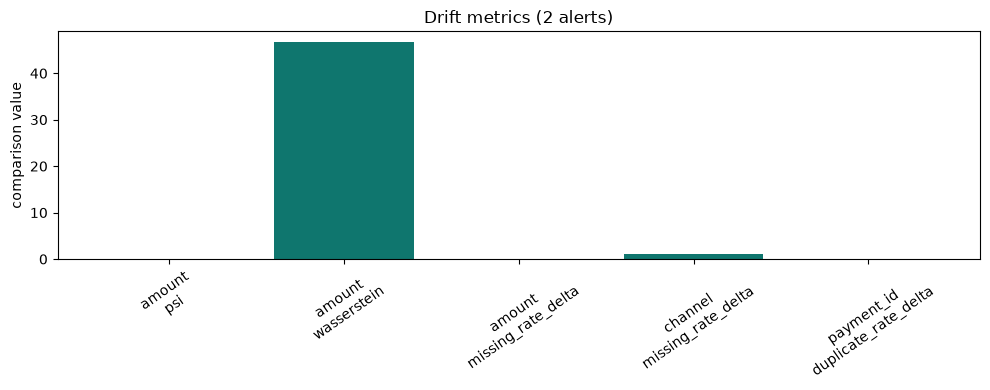

In [3]:
metrics = pl.DataFrame([metric.model_dump(mode="json") for metric in report.metrics])
display(metrics)
try:
    import matplotlib.pyplot as plt

    plot_metrics = metrics.filter(pl.col("comparison_value").is_not_null())
    labels = [
        f"{field}\n{method}"
        for field, method in plot_metrics.select(["field", "method"]).iter_rows()
    ]
    fig, axis = plt.subplots(figsize=(10, 4))
    axis.bar(labels, plot_metrics["comparison_value"].to_list(), color="#0f766e")
    axis.set(title=f"Drift metrics ({len(report.alerts)} alerts)", ylabel="comparison value")
    axis.tick_params(axis="x", labelrotation=35)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    print("Install matplotlib to render the drift-metrics plot.")

**Measure and interpret the result**


In [4]:
segment = (
    payments.group_by([c for c in ("merchant_id", "payer_account_id") if c in payments.columns])
    .len()
    .sort("len", descending=True)
    .head(10)
)
display(segment)
print("domain shift means the population mix changed; it is not automatically model failure")

merchant_id,payer_account_id,len
str,str,u32
null,"""ACC-000021""",14
null,"""ACC-000112""",13
null,"""ACC-000167""",12
null,"""ACC-000245""",10
null,"""ACC-000096""",10
null,"""ACC-000172""",10
null,"""ACC-000062""",9
null,"""ACC-000288""",9
null,"""ACC-000052""",9


domain shift means the population mix changed; it is not automatically model failure


**Exercise a parameter or failure mode**


In [5]:
from fraudtwin.ml.drift import compare_performance

performance = compare_performance(
    {"pr_auc": 0.42, "recall_at_fpr_1pct": 0.30},
    {"pr_auc": 0.31, "recall_at_fpr_1pct": 0.20},
    config=drift_config,
    label_policy="exclude_unresolved",
)
display(pl.DataFrame([metric.model_dump(mode="json") for metric in performance]))

field,field_type,method,reference_value,comparison_value,threshold,alerted,reference_count,comparison_count,metadata
str,str,str,f64,f64,f64,bool,i64,i64,struct[2]
"""pr_auc""","""performance""","""absolute_metric_delta""",0.42,0.11,0.05,true,1,1,"{0.31,""exclude_unresolved""}"
"""recall_at_fpr_1pct""","""performance""","""absolute_metric_delta""",0.3,0.1,0.05,true,1,1,"{0.2,""exclude_unresolved""}"


**Write a compact artifact and fingerprint**


In [6]:
with TemporaryDirectory(prefix="fraudtwin-drift-") as temporary_dir:
    path = Path(temporary_dir) / "drift-report.json"
    path.write_text(report.model_dump_json(indent=2), encoding="utf-8")
    print("Drift report")
    print(f"  file: {path.name}")
    print(f"  size: {path.stat().st_size:,} bytes")
    print("  lifecycle: temporary; removed when this cell exits")
    print("  next step: investigate alerts before retraining")

Drift report
  file: drift-report.json
  size: 3,121 bytes
  lifecycle: temporary; removed when this cell exits
  next step: investigate alerts before retraining


**Verify invariants and clean up**


In [7]:
summary = {
    "run_id": run_id,
    "payments": len(data.behavior.payments),
    "payment_events": len(data.behavior.payment_events),
    "fraud_records": len(data.behavior.fraud_records),
}
assert summary["payments"] == len(payments)
assert summary["payments"] > 0
summary_table = pl.DataFrame(
    [{"metric": key, "value": str(value)} for key, value in summary.items()]
)
print(summary_table)

shape: (4, 2)
┌────────────────┬──────────────────────┐
│ metric         ┆ value                │
│ ---            ┆ ---                  │
│ str            ┆ str                  │
╞════════════════╪══════════════════════╡
│ run_id         ┆ RUN-2a3ad02ee370aeb8 │
│ payments       ┆ 1092                 │
│ payment_events ┆ 4699                 │
│ fraud_records  ┆ 51                   │
└────────────────┴──────────────────────┘


## Record the generated shape and tutorial contract.


In [8]:
summary = {
    "payments": len(data.behavior.payments),
    "events": len(data.behavior.payment_events),
}
print(summary)
assert summary["payments"] >= 0

{'payments': 1092, 'events': 4699}


## Inspect stable payment identities.


In [9]:
ids = [item.payment_id for item in data.behavior.payments]
assert len(ids) == len(set(ids))
print({"unique_payment_ids": len(ids)})

{'unique_payment_ids': 1092}


## Record the generated shape and tutorial contract.


In [10]:
summary = {
    "payments": len(data.behavior.payments),
    "events": len(data.behavior.payment_events),
}
print(summary)
assert summary["payments"] >= 0

{'payments': 1092, 'events': 4699}
